# Simulation of non-linear ambiguous sensors

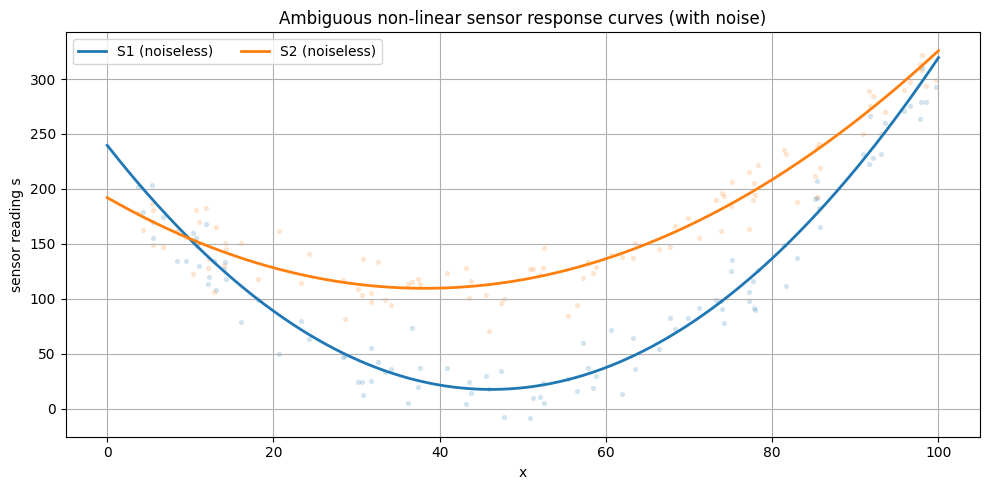

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor

rng = np.random.default_rng(42)


class AmbiguousQuadraticSensor:
    """Ambiguous sensor: convex quadratic response + linear term + Gaussian noise."""

    def __init__(self, name: str, a: float, c: float, m: float, b: float, sigma: float):
        if a <= 0:
            raise ValueError("a must be > 0 (convex parabola)")
        self.name = str(name)
        self.a = float(a)
        self.c = float(c)
        self.m = float(m)
        self.b = float(b)
        self.sigma = float(sigma)

    def forward(self, x: np.ndarray) -> np.ndarray:
        x = np.asarray(x, dtype=float)
        return self.a * (x - self.c) ** 2 + self.m * x + self.b

    def sample(self, x: np.ndarray) -> np.ndarray:
        x = np.asarray(x, dtype=float)
        noise = rng.normal(loc=0.0, scale=self.sigma, size=x.shape)
        return self.forward(x) + noise


def make_sensors(n_sensors: int, x_min: float, x_max: float):
    """Create N ambiguous sensors with different response curves."""
    sensors = []
    range = x_max - x_min
    #centers = np.linspace(x_min + 0.25*range, x_max - 0.25*range, n_sensors)
    #centers = np.linspace(x_min + 0.4*range, x_max - 0.4*range, n_sensors)
    centers = np.linspace(x_min + 0.45*range, x_max - 0.45*range, n_sensors)
    for i, c in enumerate(centers, start=1):
        a = rng.uniform(0.05, 0.12)
        m = rng.uniform(-2.0, 2.0)
        b = rng.uniform(-40.0, 40.0)
        sigma = rng.uniform(10, 20.0)
        sensors.append(AmbiguousQuadraticSensor(name=f"S{i}", a=a, c=float(c), m=m, b=b, sigma=sigma))
    return sensors


# Configuration
x_min, x_max = 0.0, 100.0
N = 2
sensors = make_sensors(N, x_min=x_min, x_max=x_max)

# Visualize ambiguous (U-shaped) response curves + noisy samples
x_grid = np.linspace(x_min, x_max, 600)
plt.figure(figsize=(10, 5))
for sensor in sensors:
    plt.plot(x_grid, sensor.forward(x_grid), lw=2, label=f"{sensor.name} (noiseless)")

n_scatter = 800
x_sc = rng.uniform(x_min, x_max, size=n_scatter)
for sensor in sensors:
    plt.scatter(x_sc[::8], sensor.sample(x_sc)[::8], s=8, alpha=0.15)

plt.xlabel("x")
plt.ylabel("sensor reading s")
plt.title("Ambiguous non-linear sensor response curves (with noise)")
plt.grid(True)
plt.legend(ncols=2)
plt.tight_layout()
plt.show()

# Machine learning

In [11]:
def make_dataset(sensors, n_samples: int, x_min: float, x_max: float):
    """Generate supervised training data: [S1..SN] -> x."""
    x = rng.uniform(x_min, x_max, size=n_samples)
    S = np.column_stack([sensor.sample(x) for sensor in sensors])
    return S, x

n_samples = 25_000
X, y = make_dataset(sensors, n_samples=n_samples, x_min=x_min, x_max=x_max)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# A very simple learning-based sensor fusion model
model = DecisionTreeRegressor(
    random_state=42,
    max_depth=12,
    min_samples_leaf=20,
)
model.fit(X_train, y_train)

# Predictions are computed here; evaluation happens in the next section
y_pred = model.predict(X_test)

In [12]:
X.shape, y.shape

((25000, 2), (25000,))

In [13]:
X_train.shape, y_train.shape

((18750, 2), (18750,))

In [14]:
X_test.shape, y_test.shape

((6250, 2), (6250,))

In [15]:
y_pred.shape

(6250,)

In [16]:
y_test[:20]

array([10.13750827, 36.37378603, 38.72916721, 28.1468571 , 45.10656397,
       56.42637118, 92.38750391, 20.49143602, 52.36271695, 80.47071   ,
       49.29449916, 24.77794144,  9.30771614, 77.65269615, 59.51809732,
       78.47781681,  9.84483329, 48.81761732, 41.02789884,  9.55041307])

In [17]:
y_pred[:20]

array([12.31890201, 39.5592972 , 41.41246441, 35.67289083, 40.96755938,
       35.67289083, 94.04918948, 30.51553067, 41.85403764, 51.00086153,
       27.83163059, 31.719526  , 48.0388757 , 80.76872914, 45.88302401,
       48.66713481, 12.31890201, 45.88302401, 43.83045403, 12.31890201])

# Evaluation

Test MAE  = 7.581
Test RMSE = 12.665


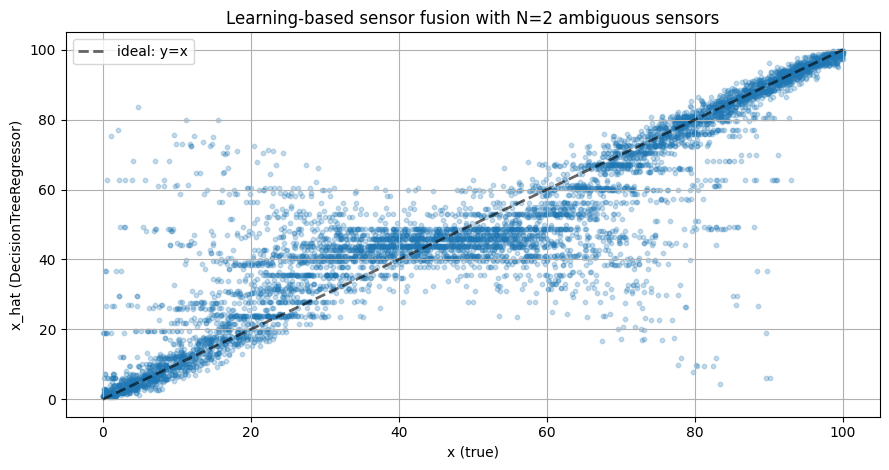

In [18]:
mae = float(mean_absolute_error(y_test, y_pred))
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
print(f"Test MAE  = {mae:.3f}")
print(f"Test RMSE = {rmse:.3f}")

# Visualization: predictions vs. ground truth
plt.figure(figsize=(9, 4.8))
plt.scatter(y_test, y_pred, s=10, alpha=0.25)
plt.plot([x_min, x_max], [x_min, x_max], "k--", lw=2, alpha=0.6, label="ideal: y=x")
plt.xlabel("x (true)")
plt.ylabel("x_hat (DecisionTreeRegressor)")
plt.title(f"Learning-based sensor fusion with N={N} ambiguous sensors")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()